In [119]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import OneClassSVM
from scipy.stats import mode

### Step 1 — Data Loading and Standardized Domain Structuring

In [120]:
# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("data_generated/observer_shift_df.csv")

# -----------------------------
# Identify columns
# -----------------------------
feature_cols = [col for col in df.columns if col.startswith("x_")]
label_col = "y_0"
domain_col = "domain"

# -----------------------------
# Extract arrays
# -----------------------------
X = df[feature_cols].values.astype(np.float32)
y = df[label_col].values.astype(np.float32)
domains = df[domain_col].values.astype(np.int64)

# -----------------------------
# Basic sanity checks
# -----------------------------
print("Total samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of domains:", len(np.unique(domains)))
print("Label shape:", y.shape)


Total samples: 5000
Number of features: 50
Number of domains: 10
Label shape: (5000,)


Basic Statistics for y_0
-------------------------
Total samples: 5000
Mean: 0.45337665
Std: 0.35434937
Min: 4.284669e-05
Max: 0.99993145
Median: 0.4114775
25th percentile: 0.09595444
75th percentile: 0.81385005


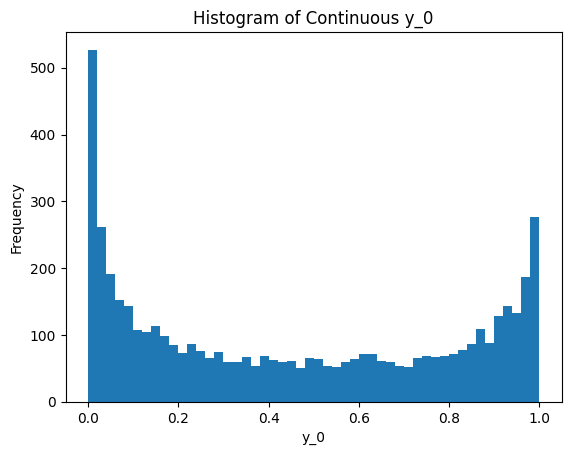

In [121]:
# Step 2: Print statistics
print("Basic Statistics for y_0")
print("-------------------------")
print("Total samples:", len(y))
print("Mean:", np.mean(y))
print("Std:", np.std(y))
print("Min:", np.min(y))
print("Max:", np.max(y))
print("Median:", np.median(y))
print("25th percentile:", np.percentile(y, 25))
print("75th percentile:", np.percentile(y, 75))

# Step 3: Plot histogram (single plot as required)
plt.figure()
plt.hist(y, bins=50)
plt.title("Histogram of Continuous y_0")
plt.xlabel("y_0")
plt.ylabel("Frequency")
plt.show()

Basic Statistics for y_0
-------------------------
Total samples: 5000
Mean: 0.45337665
Std: 0.35434937
Min: 4.284669e-05
Max: 0.99993145
Median: 0.4114775
25th percentile: 0.09595444
75th percentile: 0.81385005


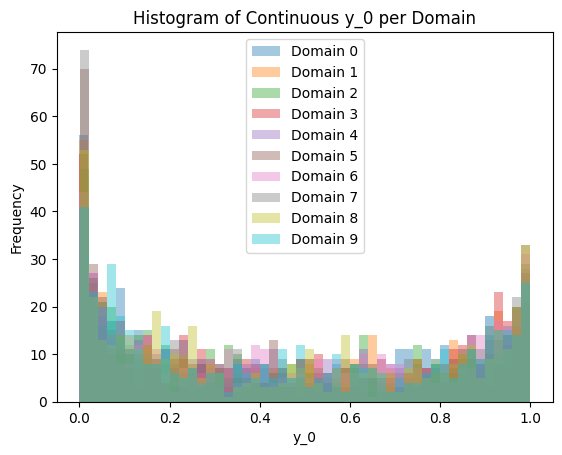

In [122]:
# -----------------------------
# Print statistics
# -----------------------------
print("Basic Statistics for y_0")
print("-------------------------")
print("Total samples:", len(y))
print("Mean:", np.mean(y))
print("Std:", np.std(y))
print("Min:", np.min(y))
print("Max:", np.max(y))
print("Median:", np.median(y))
print("25th percentile:", np.percentile(y, 25))
print("75th percentile:", np.percentile(y, 75))

# -----------------------------
# Histogram per domain (single plot, no custom colors)
# -----------------------------
plt.figure()

unique_domains = np.unique(domains)

for d in unique_domains:
    mask = domains == d
    plt.hist(y[mask], bins=50, alpha=0.4, label=f"Domain {d}")

plt.title("Histogram of Continuous y_0 per Domain")
plt.xlabel("y_0")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [123]:
# Use global median threshold
threshold = np.median(y)
y_binary = (y > threshold).astype(np.int64)

# Print balance information
print("Threshold used (median):", threshold)
print("Total samples:", len(y_binary))
print("Class 0 count:", np.sum(y_binary == 0))
print("Class 1 count:", np.sum(y_binary == 1))
print("Class 1 proportion:", np.mean(y_binary))

# Replace y with binary version if desired
y = y_binary


Threshold used (median): 0.4114775
Total samples: 5000
Class 0 count: 2500
Class 1 count: 2500
Class 1 proportion: 0.5


In [124]:
df_check = pd.DataFrame({
    "y": y,
    "domain": domains
})

# Compute counts per domain
counts = df_check.groupby("domain")["y"].value_counts().unstack(fill_value=0)
# Also print proportions per domain
proportions = counts.div(counts.sum(axis=1), axis=0)
print("\nClass proportions per domain:")
proportions


Class proportions per domain:


y,0,1
domain,,
0,0.542,0.458
1,0.470,0.530
2,0.502,0.498
3,0.490,0.510
4,0.494,0.506
5,0.526,0.474
6,0.470,0.530
7,0.518,0.482
8,0.496,0.504


In [125]:
unique_domains = np.unique(domains)

domain_indices = {
    d: np.where(domains == d)[0]
    for d in unique_domains
}


### Step 2 — Unified Model Training Interface (Modular Trainers)

Classical

In [126]:
def train_logistic_regression(X_train, y_train, domains_train=None):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return model


In [127]:
def train_random_forest(X_train, y_train, domains_train=None):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


In [128]:
def train_svm(X_train, y_train, domains_train=None):
    model = SVC(
        kernel="rbf",
        probability=True  # needed for predict_proba
    )
    model.fit(X_train, y_train)
    return model


In [129]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_nn_erm(X_train, y_train, domains_train=None,
                 epochs=50, lr=1e-3, batch_size=128):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    model = SimpleNN(X_train.shape[1]).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model


Regularized

In [130]:
def train_nn_l2(X_train, y_train, domains_train=None,
                epochs=50, lr=1e-3, batch_size=128,
                weight_decay=1e-4):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    model = SimpleNN(X_train.shape[1]).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay  # L2 regularization
    )

    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model


In [131]:
class DropoutNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_nn_dropout(X_train, y_train, domains_train=None,
                     epochs=50, lr=1e-3, batch_size=128,
                     dropout_p=0.5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

    model = DropoutNN(
        input_dim=X_train.shape[1],
        dropout_p=dropout_p
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model

Domain Aware

In [132]:
def train_vrex(X_train, y_train, domains_train,
               epochs=50, lr=1e-3,
               batch_size=100,
               lambda_vrex=1.0):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    d_tensor = torch.tensor(domains_train, dtype=torch.long).to(device)

    model = SimpleNN(X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss(reduction='none')  # important

    unique_domains = torch.unique(d_tensor)
    n_domains = len(unique_domains)
    samples_per_domain = batch_size // n_domains

    model.train()

    for _ in range(epochs):

        # Shuffle indices per domain
        domain_indices = {
            d.item(): torch.where(d_tensor == d)[0][
                torch.randperm((d_tensor == d).sum())
            ]
            for d in unique_domains
        }

        # Determine number of balanced batches
        min_samples = min(len(idx) for idx in domain_indices.values())
        n_batches = min_samples // samples_per_domain

        for b in range(n_batches):

            batch_indices = []

            for d in unique_domains:
                idx = domain_indices[d.item()]
                start = b * samples_per_domain
                end = start + samples_per_domain
                batch_indices.append(idx[start:end])

            batch_indices = torch.cat(batch_indices)

            xb = X_tensor[batch_indices]
            yb = y_tensor[batch_indices]
            db = d_tensor[batch_indices]

            optimizer.zero_grad()

            logits = model(xb)
            losses = criterion(logits, yb)

            # Compute domain-wise risks
            domain_risks = []
            for d in unique_domains:
                mask = (db == d)
                if mask.sum() > 0:
                    domain_risks.append(losses[mask].mean())

            domain_risks = torch.stack(domain_risks)

            mean_risk = domain_risks.mean()
            variance_penalty = domain_risks.var(unbiased=False)

            loss = mean_risk + lambda_vrex * variance_penalty

            loss.backward()
            optimizer.step()

    return model


In [133]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_grl * grad_output, None


class GradientReversal(nn.Module):
    def __init__(self, lambda_grl=1.0):
        super().__init__()
        self.lambda_grl = lambda_grl

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_grl)


class DANN(nn.Module):
    def __init__(self, input_dim, n_domains, hidden_dim=128, lambda_grl=1.0):
        super().__init__()

        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Label predictor
        self.label_classifier = nn.Linear(hidden_dim, 1)

        # Domain classifier
        self.grl = GradientReversal(lambda_grl)
        self.domain_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_domains)
        )

    def forward(self, x):
        features = self.feature_extractor(x)

        label_logits = self.label_classifier(features)

        reversed_features = self.grl(features)
        domain_logits = self.domain_classifier(reversed_features)

        return label_logits, domain_logits


def train_dann(X_train, y_train, domains_train,
               epochs=50, lr=1e-3, batch_size=128,
               lambda_grl=1.0, lambda_domain=1.0):

    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # -----------------------------
    # Remap domain labels to 0...K-1
    # -----------------------------
    unique_domains = np.unique(domains_train)
    domain_mapping = {d: i for i, d in enumerate(unique_domains)}
    domains_train_mapped = np.array([domain_mapping[d] for d in domains_train])

    # -----------------------------
    # Tensors
    # -----------------------------
    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    d_tensor = torch.tensor(domains_train_mapped, dtype=torch.long).to(device)

    n_domains = len(unique_domains)

    # -----------------------------
    # Model
    # -----------------------------
    model = DANN(
        input_dim=X_train.shape[1],
        n_domains=n_domains,
        lambda_grl=lambda_grl
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    label_criterion = nn.BCEWithLogitsLoss()
    domain_criterion = nn.CrossEntropyLoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor, d_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()

    for _ in range(epochs):
        for xb, yb, db in loader:

            optimizer.zero_grad()

            label_logits, domain_logits = model(xb)

            label_loss = label_criterion(label_logits, yb)
            domain_loss = domain_criterion(domain_logits, db)

            loss = label_loss + lambda_domain * domain_loss

            loss.backward()
            optimizer.step()

    return model



Premise Based

In [134]:
# =========================
# Train SVM Region
# =========================
def train_svm_region(x1, x2):
    if x2.ndim == 1:
        x2 = x2.reshape(-1, 1)
    X = np.hstack([x1, x2])
    svm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
    svm.fit(X)
    return svm


# =========================
# Differentiable SVM Wrapper
# =========================
class SVMPremise(nn.Module):
    def __init__(self, svm_model):
        super().__init__()

        self.support_vectors = torch.tensor(
            svm_model.support_vectors_, dtype=torch.float32
        )
        self.alpha = torch.tensor(
            svm_model.dual_coef_.flatten(), dtype=torch.float32
        )
        self.rho = torch.tensor(
            svm_model.intercept_[0], dtype=torch.float32
        )
        self.gamma = svm_model._gamma

    def rbf_kernel(self, X1, X2):
        sq1 = (X1**2).sum(dim=1, keepdim=True)
        sq2 = (X2**2).sum(dim=1, keepdim=True)
        sqdist = sq1 + sq2.T - 2 * X1 @ X2.T
        return torch.exp(-self.gamma * sqdist)

    def raw_decision(self, x1, x2_pred):
        X = torch.cat([x1, x2_pred], dim=1)
        K = self.rbf_kernel(self.support_vectors, X)
        f = self.alpha @ K + self.rho
        return f

    def forward(self, x1, x2_pred):
        f = self.raw_decision(x1, x2_pred)
        return torch.relu(-f)   # penalty


# =========================
# Debug Helpers
# =========================
def debug_epoch(epoch, loss, model, premise, x1_t, pred, mode):
    print(f"\nEpoch: {epoch}")
    print("Loss:", loss.item())

    if mode != "plain" and premise is not None:
        with torch.no_grad():
            penalty_vals = premise(x1_t, pred)
            raw_vals = premise.raw_decision(x1_t, pred)

            print("Penalty min:", penalty_vals.min().item())
            print("Penalty max:", penalty_vals.max().item())

            print("Raw decision min:", raw_vals.min().item())
            print("Raw decision max:", raw_vals.max().item())

    print("Gradient norms:")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(f"{name}: {param.grad.norm().item()}")

    print("-" * 50)


# =========================
# Training Function
# =========================
def train_model(x1, x2, domains_train=None,
                mode="combined",
                lambda_premise=0.1,
                epochs=50,
                lr=1e-3,
                batch_size=128,
                debug=False):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ----------------------------
    # Tensors
    # ----------------------------
    X_tensor = torch.tensor(x1, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(x2, dtype=torch.float32).unsqueeze(1).to(device)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset,
                                         batch_size=batch_size,
                                         shuffle=True)

    # ----------------------------
    # Model
    # ----------------------------
    model = SimpleNN(x1.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    # ----------------------------
    # Train SVM(s)
    # ----------------------------
    premises = None

    if mode in ["combined", "premise_only"]:

        # If domains available → multi-domain SVM
        if domains_train is not None:
            unique_domains = np.unique(domains_train)
            premises = []

            for d in unique_domains:
                mask = domains_train == d
                svm_d = train_svm_region(x1[mask], x2[mask])
                premises.append(SVMPremise(svm_d).to(device))

            n_domains = len(premises)

        # Otherwise → global SVM
        else:
            svm = train_svm_region(x1, x2)
            premises = [SVMPremise(svm).to(device)]
            n_domains = 1

    # ----------------------------
    # Training Loop
    # ----------------------------
    model.train()

    for epoch in range(epochs):

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model(xb)

            # ----------------------------
            # Plain ERM
            # ----------------------------
            if mode == "plain":
                loss = criterion(logits, yb)

            # ----------------------------
            # Combined Loss
            # ----------------------------
            elif mode == "combined":

                task_loss = criterion(logits, yb)

                total_premise_loss = 0.0

                for premise in premises:
                    # Use logits directly as predicted y
                    premise_loss = premise(xb, logits).mean()
                    total_premise_loss += premise_loss

                total_premise_loss /= n_domains

                loss = task_loss + lambda_premise * total_premise_loss

            # ----------------------------
            # Premise Only
            # ----------------------------
            elif mode == "premise_only":

                total_premise_loss = 0.0

                for premise in premises:
                    premise_loss = premise(xb, logits).mean()
                    total_premise_loss += premise_loss

                loss = total_premise_loss / n_domains

            else:
                raise ValueError("mode must be 'plain', 'combined', or 'premise_only'")

            loss.backward()
            optimizer.step()

        if debug and epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss {loss.item()}")

    return model


In [135]:
def train_model_multi_domain(x1, x2, domains_train=None,
                             mode="combined",
                             lambda_premise=0.1,
                             epochs=50,
                             lr=1e-3,
                             batch_size=128,
                             debug=False):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ----------------------------
    # Tensors
    # ----------------------------
    X_tensor = torch.tensor(x1, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(x2, dtype=torch.float32).unsqueeze(1).to(device)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader = torch.utils.data.DataLoader(dataset,
                                         batch_size=batch_size,
                                         shuffle=True)

    # ----------------------------
    # Model
    # ----------------------------
    model = SimpleNN(x1.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    # ----------------------------
    # Train SVM per domain
    # ----------------------------
    premises = None

    if mode in ["combined", "premise_only"] and domains_train is not None:

        unique_domains = np.unique(domains_train)
        premises = []

        for d in unique_domains:
            mask = domains_train == d
            svm_d = train_svm_region(x1[mask], x2[mask])
            premises.append(SVMPremise(svm_d).to(device))

        n_domains = len(premises)
    else:
        premises = None
        n_domains = 1

    # ----------------------------
    # Training Loop
    # ----------------------------
    model.train()

    for epoch in range(epochs):

        for xb, yb in loader:

            optimizer.zero_grad()

            logits = model(xb)

            # ----------------------------
            # Plain ERM
            # ----------------------------
            if mode == "plain":
                loss = criterion(logits, yb)

            # ----------------------------
            # Combined
            # ----------------------------
            elif mode in ["combined", "premise_only"]:

                total_premise_loss = 0.0

                for premise in premises:
                    premise_loss = premise(xb, logits).mean()
                    total_premise_loss += premise_loss

                total_premise_loss /= n_domains

                if mode == "combined":
                    task_loss = criterion(logits, yb)
                    loss = task_loss + lambda_premise * total_premise_loss
                else:
                    loss = total_premise_loss

            else:
                raise ValueError("mode must be 'plain', 'combined', or 'premise_only'")

            loss.backward()
            optimizer.step()

        if debug and epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss {loss.item()}")

    return model


In [136]:
class DomainMajoritySVM:
    def __init__(self):
        self.models = []
        self.unique_domains = None

    def fit(self, X_train, y_train, domains_train):
        self.unique_domains = np.unique(domains_train)
        self.models = []

        for d in self.unique_domains:
            mask = domains_train == d
            model_d = SVC(kernel="rbf", probability=True)
            model_d.fit(X_train[mask], y_train[mask])
            self.models.append(model_d)

    def predict(self, X):
        # Collect predictions from all domain models
        all_preds = np.array([model.predict(X) for model in self.models])
        # Majority vote across domains
        majority_preds = mode(all_preds, axis=0).mode[0]
        return majority_preds

    def predict_proba(self, X):
        # Average probabilities across domains
        all_probs = np.array([model.predict_proba(X) for model in self.models])
        mean_probs = all_probs.mean(axis=0)
        return mean_probs

def train_domain_majority_svm(X_train, y_train, domains_train):
    model = DomainMajoritySVM()
    model.fit(X_train, y_train, domains_train)
    return model

### Step 3 — Leave-One-Domain-Out Evaluation Protocol

In [137]:
def get_probabilities(model, X):
    
    # sklearn models
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    # torch models
    elif isinstance(model, torch.nn.Module):
        device = next(model.parameters()).device
        model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

        with torch.no_grad():
            output = model(X_tensor)

            # DANN returns tuple
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            probs = torch.sigmoid(logits).cpu().numpy().flatten()

        return probs

    else:
        raise ValueError("Unsupported model type.")


In [138]:
def evaluate_lodo(train_function,
                  model_name,
                  X, y, domains,
                  threshold=0.5,
                  **train_kwargs):

    import numpy as np

    unique_domains = np.unique(domains)

    all_probs = []
    all_true = []
    all_test_domains = []
    all_fold_ids = []

    for fold_id, test_domain in enumerate(unique_domains):

        # Split data
        train_mask = domains != test_domain
        test_mask = domains == test_domain

        X_train, y_train = X[train_mask], y[train_mask]
        d_train = domains[train_mask]

        X_test, y_test = X[test_mask], y[test_mask]
        d_test = domains[test_mask]

        # Train model
        model = train_function(
            X_train, y_train, d_train,
            **train_kwargs
        )

        # Get probabilities (unified function)
        probs = get_probabilities(model, X_test)

        # Store fold results
        all_probs.append(probs)
        all_true.append(y_test)
        all_test_domains.append(d_test)
        all_fold_ids.append(np.full_like(y_test, fold_id))

    # Concatenate everything
    all_probs = np.concatenate(all_probs)
    all_true = np.concatenate(all_true)
    all_domains = np.concatenate(all_test_domains)
    all_folds = np.concatenate(all_fold_ids)

    results = {
        "model_name": model_name,
        "y_true": all_true,
        "y_prob": all_probs,
        "y_pred": (all_probs >= threshold).astype(int),
        "domain_id": all_domains,
        "fold_id": all_folds
    }

    return results


### Step 4 — Multi-model benchmark wrapper.

In [139]:
def run_benchmark(models_dict,
                  X, y, domains,
                  threshold=0.5):
    """
    Runs LODO evaluation for multiple models.

    Parameters
    ----------
    models_dict : dict
        Dictionary of form:
        {
            "ModelName": {
                "train_function": function,
                "train_kwargs": dict
            },
            ...
        }

    Returns
    -------
    all_results : dict
        Dictionary containing results per model.
    """

    all_results = {}

    for model_name, model_info in models_dict.items():

        print(f"Running LODO for: {model_name}")

        train_function = model_info["train_function"]
        train_kwargs = model_info.get("train_kwargs", {})

        results = evaluate_lodo(
            train_function=train_function,
            model_name=model_name,
            X=X,
            y=y,
            domains=domains,
            threshold=threshold,
            **train_kwargs
        )

        all_results[model_name] = results

    return all_results


### Step 5 — Experiment Execution and Logging

In [ ]:
models = {
    "Logistic": {
        "train_function": train_logistic_regression
    },
    "RandomForest": {
        "train_function": train_random_forest
    },
    "SVM": {
        "train_function": train_svm
    },
    "NN_ERM": {
        "train_function": train_nn_erm
    },
    "NN_L2": {
        "train_function": train_nn_l2,
        "train_kwargs": {"weight_decay": 1e-4}
    },
    "NN_Dropout": {
        "train_function": train_nn_dropout,
        "train_kwargs": {"dropout_p": 0.5}
    },
    "VREx": {
        "train_function": train_vrex,
        "train_kwargs": {"lambda_vrex": 1.0}
    },
    "DANN": {
        "train_function": train_dann,
        "train_kwargs": {"lambda_grl": 1.0, "lambda_domain": 0.1}
    },
    "SVM_DomainMajority": {
        "train_function": train_domain_majority_svm
    },
    "NN_SVM_Global": {
        "train_function": train_model,
        "train_kwargs": {"mode": "combined", "lambda_premise": 0.1}
    },
    "NN_SVM_Only_Global": {
        "train_function": train_model, 
        "train_kwargs": {"mode": "premise_only"}
    },
    "NN_SVM_MultiDomain": {
        "train_function": train_model_multi_domain,
        "train_kwargs": {"mode": "combined", "lambda_premise": 0.1}
    }
}


In [141]:
all_results = run_benchmark(models, X, y, domains)

Running LODO for: Logistic
Running LODO for: RandomForest
Running LODO for: SVM
Running LODO for: NN_ERM
Running LODO for: NN_L2
Running LODO for: NN_Dropout
Running LODO for: VREx
Running LODO for: DANN
Running LODO for: SVM_DomainMajority
Running LODO for: NN_SVM_Global
Running LODO for: NN_SVM_Only_Global
Running LODO for: NN_SVM_MultiDomain


In [142]:
import pickle

with open("results/observer_benchmark_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

print("Results saved to observer_benchmark_results.pkl")


Results saved to observer_benchmark_results.pkl
